# Diamonds

## Column Definitions

| Column Name | Data Type | Description | Values / Range |
| :--- | :--- | :--- | :--- |
| `carat` | `float64` | Weight of the diamond | 0.20 – 5.01 |
| `cut` | `category` | Quality of the cut | Fair < Good < Very Good < Premium < Ideal |
| `color` | `category` | Diamond color rating | J (worst) to D (best) |
| `clarity` | `category` | Clarity rating | I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best) |
| `depth` | `float64` | Total depth percentage = 2 * z / (x + y) | 43.0 – 79.0 |
| `table` | `float64` | Width of top of diamond relative to widest point | 43.0 – 95.0 |
| `price` | `int64` | Price in US dollars | $326 – $18,823 |
| `x` | `float64` | Length in mm | 0.0 – 10.74 |
| `y` | `float64` | Width in mm | 0.0 – 58.90 |
| `z` | `float64` | Depth in mm | 0.0 – 31.80 |

### 1. Setup and Data inspection

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid") # set visual theme/aesthetic

# load built-in diamonds dataset
df = sns.load_dataset('diamonds')

print(f"Dataset dimensions: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nData types & info: ")
print(df.info())

df.head()

Dataset dimensions: 53940 rows x 10 columns

Data types & info: 
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### 2. Anomaly Detection & Cleaning (Invalid Dimensions)
Diamonds cannot mathematically have a length (`x`), width (`y`), or depth (`z`) of 0 mm. We need to inspect and filter out these physical measurement errors before plotting.

In [2]:
# check for physically impossible zero dimensions
zero_dims = df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)]
print(f"Number of rows with invalid 0mm dimensions: {len(zero_dims)}")

# safe deep copy excluding invalid dimensional anomalies
df_clean = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)].copy() # getting each records that has no 0 values on all x, y, z
print(f"Cleaned Dataset Shape: {df_clean.shape}")

Number of rows with invalid 0mm dimensions: 20
Cleaned Dataset Shape: (53920, 10)


### 3. Feature Engineering (Volume & Efficiency Metrics)
Raw physical dimensions (`x`, `y`, `z`) are better expressed as a single 3D metric (`volume`) alongside a normalized rate (`price_per_carat`).

In [4]:
df_clean['volume'] = df_clean['x'] * df_clean['y'] * df_clean['z'] # creating new column 'volume'
df_clean['price_per_carat'] = df_clean['price']/df_clean['carat'] # creating enw column 'price_per_carat'

# inspect summary stats for engineered features
df_clean[['carat', 'price', 'volume', 'price_per_carat']].describe().round(2)

,carat,price,volume,price_per_carat
count,53920.00,53920.00,53920.00,53920.00
mean,0.80,3930.99,129.90,4007.83
std,0.47,3987.28,78.22,2012.18
min,0.20,326.00,31.71,1051.16
25%,0.40,949.00,65.19,2477.67
50%,0.70,2401.00,114.84,3494.63
75%,1.04,5323.25,170.85,4949.02
max,5.01,18823.00,3840.60,17828.85


### 4. Distribution Analysis (Identifying Skewness)
Plotting histograms with KDE to visualize the right-skewness in `price` and `carat`.

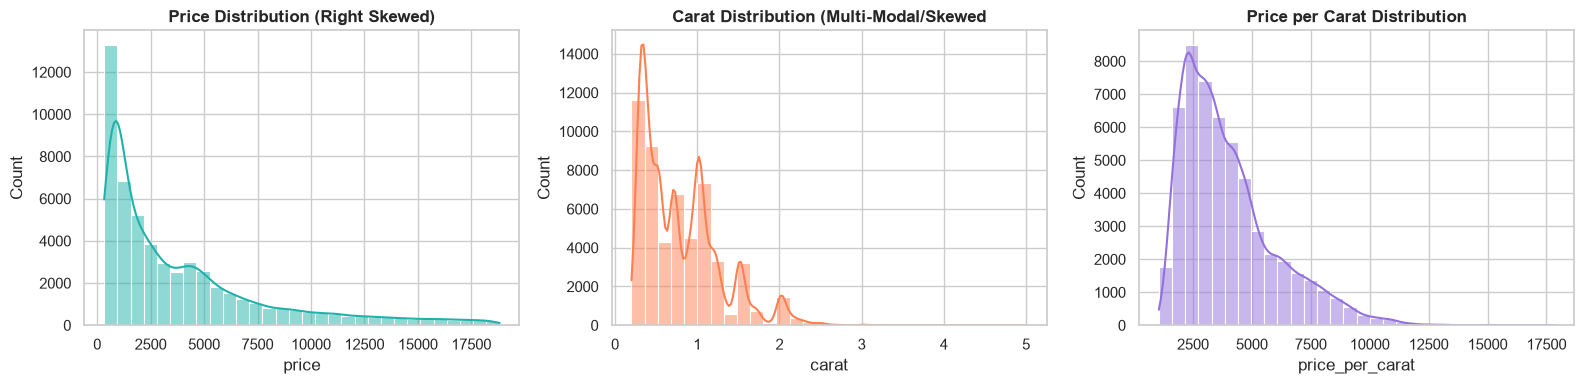

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4)) # setting canvas; 3 plots in 1 row

# 1. price distribution (heavily right-skewed); first plot
sns.histplot(df_clean['price'], kde=True, ax=axes[0], color='lightseagreen', bins=30)
axes[0].set_title('Price Distribution (Right Skewed)', fontweight='bold')

# 2. carat distribution (right-skewed with peaks at round numbers); second plot
sns.histplot(df_clean['carat'], kde=True, ax=axes[1], color='coral', bins=30)
axes[1].set_title('Carat Distribution (Multi-Modal/Skewed', fontweight='bold')

# price per carat distribution; third plot
sns.histplot(df_clean['price_per_carat'], kde=True, ax=axes[2], color='mediumpurple', bins=30)
axes[2].set_title('Price per Carat Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

### 5. Uncovering the Non-Linear Relationship (Raw vs. Log-Log)
Applying Log-Log transformation (`np.log1p` on both variables) to linearize the relationship.

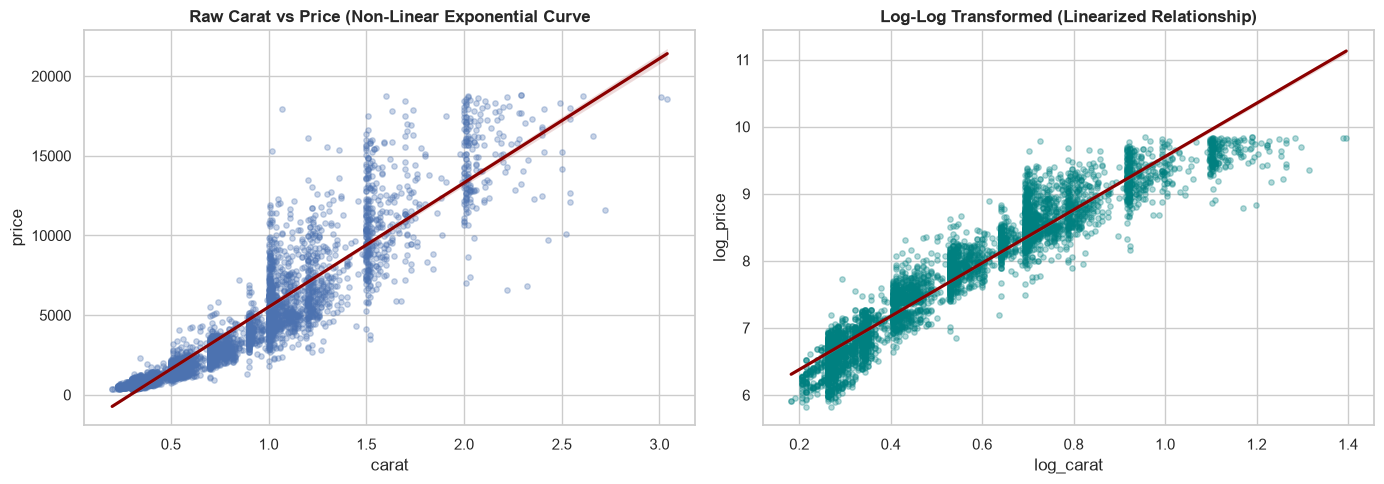

In [9]:
# apply log transformations to compress right-skewed tails
df_clean['log_price'] = np.log1p(df_clean['price'])
df_clean['log_carat'] = np.log1p(df_clean['carat'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # setting up canvas; 2 plots in 1 row

# plot 1: raw exponential curve
sns.regplot(
    data=df_clean.sample(5000, random_state=42),
    x='carat', 
    y='price',
    ax=axes[0],
    scatter_kws={'alpha': 0.3, 's': 15},
    line_kws={'color': 'darkred'}
)
axes[0].set_title('Raw Carat vs Price (Non-Linear Exponential Curve', fontweight='bold')

# plot 2: log-log linearized relationship
sns.regplot(
    data=df_clean.sample(5000, random_state=42),
    x='log_carat',
    y='log_price',
    ax=axes[1],
    scatter_kws={'alpha': 0.3, 's': 15, 'color': 'teal'},
    line_kws={'color': 'darkred'}
)
axes[1].set_title('Log-Log Transformed (Linearized Relationship)', fontweight='bold')

plt.tight_layout()
plt.show()

### 6. Categorical Subgroup Interaction Regressions (`sns.lmplot`)
Evaluate how quality factors like `cut` shift the price regression trendline. 

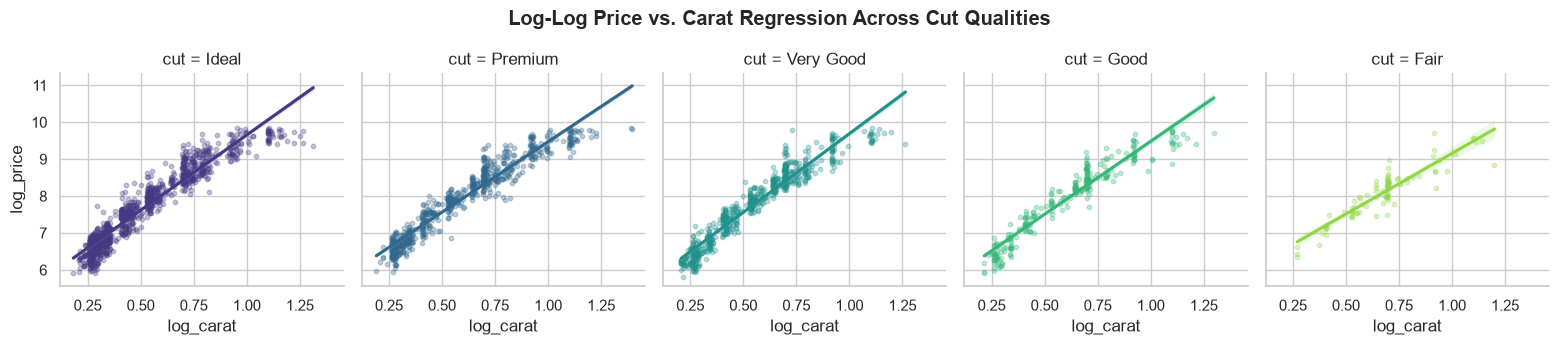

In [11]:
# sample 3000 rows for clean faceting display
df_sample = df_clean.sample(3000, random_state=42)

sns.lmplot(
    data=df_sample,
    x='log_carat',
    y='log_price',
    hue='cut',
    col='cut',
    col_wrap=5,
    palette='viridis',
    height=3.5,
    aspect=0.9,
    scatter_kws={'alpha': 0.3, 's': 10}
)

plt.subplots_adjust(top=0.8)
plt.suptitle('Log-Log Price vs. Carat Regression Across Cut Qualities', fontweight='bold')
plt.show()

### 7. Correlation Heatmap (Raw vs. Log Features)
Examine how logarithmic transformations improve correlation metrics across physical and pricing features. 

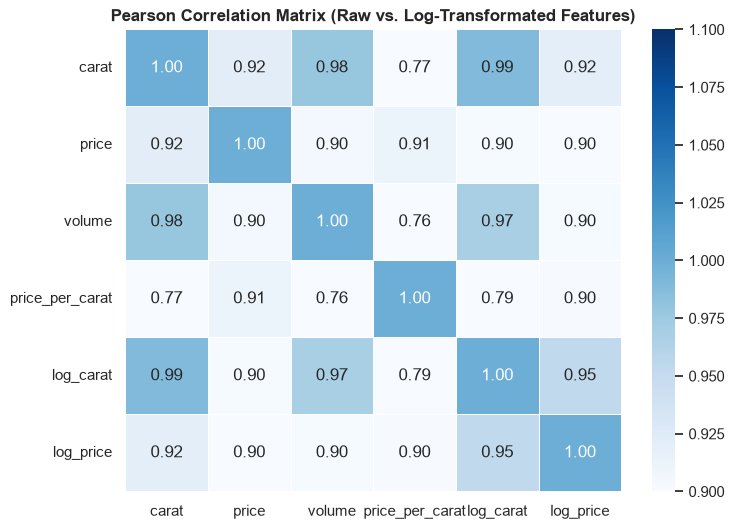

In [12]:
# selecting key numerical columns
num_cols = ['carat', 'price', 'volume', 'price_per_carat', 'log_carat', 'log_price']
corr_matrix = df_clean[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="Blues",
            vmin=1,
            vmax=1,
            linewidths=0.5)
plt.title('Pearson Correlation Matrix (Raw vs. Log-Transformated Features)', fontweight='bold')
plt.show()

### Executive Summary & Key Analytical Findings

#### 1. Non-Linearity & Exponential Valuation Growth
* **Exponential Curve:** Raw `carat` weight vs. `price` exhibits severe **exponential growth**. Diamond prices do not scale linearly; doubling the carat size quadruples or quintuples the price due to rarity.
* **Log-Log Linearization:** Applying a dual logarithmic transformation (`log_carat` and `log_price` using `np.log1p`) successfully linearizes the relationship, converting an exponential curve into a clean linear trend ideal for regression algorithms.

---

#### 2. Physical Dimensions & Volume Synergy
* **Dimensional Anomalies Filtered:** Identified and eliminated rows where physical dimensions (`x`, `y`, `z`) equaled `0mm`.
* **Volume Correlation:** Engineered 3D `volume` ($x \times y \times z$) correlates nearly identically to `carat` weight ($r \approx 0.98$), confirming that physical volume is the underlying driver of mass and price.

---

#### 3. Sub-Group Interactions & Quality Premium
* **Cut Premium:** Holding `log_carat` constant, higher cut grades (`Ideal`, `Premium`) consistently maintain higher intercept baselines on pricing plots compared to lower cut grades (`Fair`).